<a href="https://colab.research.google.com/github/WanjaWhoopie/ABDN-Fellowship/blob/main/Whoopie's_Copy_of_Session21_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 73.6 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [1]:
import os
import mne
import urllib.request
import numpy as np
import pandas as pd
import re
import requests
from tqdm import tqdm
import matplotlib.pyplot as plt

mne.set_log_level('Warning')

In [2]:
# Configuration and Parameter Dictionary
CONFIG = {
    'tmin': -5.0,
    'tmax': 15.0,
    'baseline': (None, 0.0),
    'reject_ptp': dict(eeg=250e-6),
    'flat_ptp': dict(eeg=1e-6)
}

In [3]:
BASE_URL = "https://physionet.org/files/chbmit/1.0.0/{subj}/{subj}-summary.txt"
SUBJECT_IDS = [f"chb{n:02d}" for n in range(1, 25)]

In [4]:
def fetch_summary(subject_id: str) -> str | None:
    resp = requests.get(BASE_URL.format(subj=subject_id), timeout=20)
    return resp.text if resp.status_code == 200 else None

In [5]:
def parse_summary(text: str) -> list[dict]:
    entries = []
    blocks = re.split(r"(?=File Name:)", text)
    for block in blocks:
        fname_match = re.search(r"File Name:\s*(\S+)", block)
        nseiz_match = re.search(r"Number of Seizures in File:\s*(\d+)", block)
        if not fname_match or not nseiz_match or int(nseiz_match.group(1)) == 0:
            continue

        for onset in re.findall(r"Seizure(?:\s+\d+)?\s+Start Time:\s*(\d+)\s*seconds", block):
            entries.append({"file_name": fname_match.group(1), "seizure_onset": int(onset)})
    return entries

In [6]:
cohort_dict = {subj: parse_summary(text) for subj in SUBJECT_IDS if (text := fetch_summary(subj))}
cohort_df = pd.DataFrame([{"subject_id": s, **e} for s, entries in cohort_dict.items() for e in entries])
print(f"Total seizure events logged: {len(cohort_df)}")

Total seizure events logged: 198


In [7]:
all_raws = []
EDF_BASE_URL = "https://physionet.org/files/chbmit/1.0.0/"
sample_df = cohort_df.head(3)

In [8]:
for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Fetching EDFs"):
  fname = row['file_name']
  url = f"{EDF_BASE_URL}{row['subject_id']}/{fname}"

  if not os.path.exists(fname):
      urllib.request.urlretrieve(url, fname)

  raw = mne.io.read_raw_edf(fname, preload=True, verbose=False)

  # Inject annotations: 40s Background (at 10s) and Seizure onset
  annotations = mne.Annotations(
      onset=[10.0, row['seizure_onset']],
      duration=[40.0, 40.0],
      description=['Non-Seizure', 'Seizure']
  )
  raw.set_annotations(annotations)

  new_names = {ch: ch.replace('EEG ', '').replace('-REF', '').strip() for ch in raw.ch_names}
  raw.rename_channels(new_names)
  all_raws.append(raw)

Fetching EDFs:   0%|          | 0/3 [00:00<?, ?it/s]/tmp/ipykernel_1962/3993855032.py:8: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(fname, preload=True, verbose=False)
Fetching EDFs:  33%|███▎      | 1/3 [16:27<32:55, 987.75s/it]/tmp/ipykernel_1962/3993855032.py:8: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(fname, preload=True, verbose=False)
Fetching EDFs:  67%|██████▋   | 2/3 [32:14<16:03, 963.38s/it]/tmp/ipykernel_1962/3993855032.py:8: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(fname, preload=True, verbose=False)
Fetching EDFs: 100%|██████████| 3/3 [46:38<00:00, 932.88s/it]


In [9]:
CONFIG['reject_ptp'] = dict(eeg=2500e-6)

raw_cohort = mne.concatenate_raws(all_raws, verbose=False)
raw_cohort.filter(l_freq=1.0, h_freq=50.0, verbose=False) # Bandpass filter

events, event_dict = mne.events_from_annotations(raw_cohort, verbose=False)
cohort_epochs = mne.Epochs(
    raw=raw_cohort, events=events, event_id={'Seizure': event_dict['Seizure'], 'Non-Seizure': event_dict['Non-Seizure']},
    tmin=CONFIG['tmin'], tmax=CONFIG['tmax'], baseline=CONFIG['baseline'],
    preload=True, reject=CONFIG['reject_ptp'], flat=CONFIG['flat_ptp'], verbose=False
)
print(f"\nPipeline Complete! Retained {len(cohort_epochs)} epochs.")


Pipeline Complete! Retained 6 epochs.


In [17]:
#@title Part A - Welch's Method

#compute PSD using Welch's method (1 - 50Hz range)
psd_welch = cohort_epochs.compute_psd(method='welch', fmin=1, fmax=50, n_fft=256, n_overlap=128)

# Extract underlying data and frequencies
psd_data = psd_welch.get_data()
freqs = psd_welch.freqs

print(f"PSD Array Shape: {psd_data.shape} (Epochs, channels, frequencies)")


PSD Array Shape: (6, 23, 50) (Epochs, channels, frequencies)


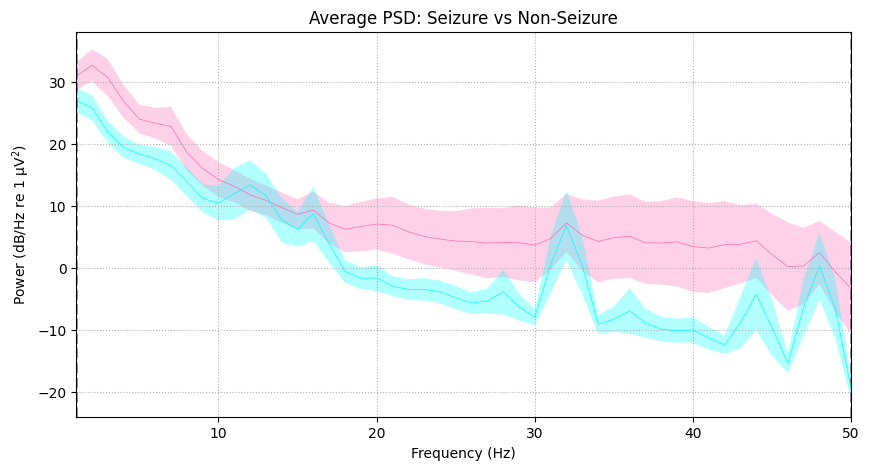

In [18]:
# Visualise average PSD split by condition
fig, ax = plt.subplots(figsize=(10,5))
psd_welch['Seizure'].plot(average=True, axes=ax, color='hotpink', show=False)
psd_welch['Non-Seizure'].plot(average=True, axes=ax, color='cyan', show=False)
ax.set_title('Average PSD: Seizure vs Non-Seizure')
plt.show()


In [19]:
#@title Part B & C - Biomarker Extraction & Export

# Identify frontal channels
frontal_channels = [ch for ch in cohort_epochs.ch_names if 'F' in ch]
frontal_indices = [cohort_epochs.ch_names.index(ch) for ch in frontal_channels]

In [20]:
# Slice frequency array (4-8 Hz for Theta)
theta_idx = np.where((freqs >= 4) & (freqs <= 8))[0]

# Slice and average power. Slice: [All Epochs, frontal channels, theta frequencies]
theta_power = psd_data[:, frontal_indices, :][:, :, theta_idx]
mean_theta = theta_power.mean(axis=2).mean(axis=1)

In [21]:
# Create dataframe tracking condition of each epoch. Map numeric event codes back to their string labels
inv_event_dict = {v: k for k, v in cohort_epochs.event_id.items()}
condition_labels = [inv_event_dict[event_code] for event_code in cohort_epochs.events[:, 2]]


df_spectral = pd.DataFrame({
    'Epoch_ID': range(len(cohort_epochs)),
    'Condition': condition_labels,
    'Frontal_Theta_Power': mean_theta
})

display(df_spectral.head())

,Epoch_ID,Condition,Frontal_Theta_Power
0,0,Non-Seizure,4.025677e-11
1,1,Seizure,2.909962e-10
2,2,Non-Seizure,3.927414e-11
3,3,Seizure,3.471490e-10
4,4,Non-Seizure,1.180155e-10


In [22]:
df_spectral

,Epoch_ID,Condition,Frontal_Theta_Power
0,0,Non-Seizure,4.025677e-11
1,1,Seizure,2.909962e-10
2,2,Non-Seizure,3.927414e-11
3,3,Seizure,3.471490e-10
4,4,Non-Seizure,1.180155e-10
5,5,Seizure,3.021904e-10


In [23]:
#@title Your Turn
# 1. Identify occipital channels
occipital_channels = [ch for ch in cohort_epochs.ch_names if 'O' in ch]
occipital_indices = [cohort_epochs.ch_names.index(ch) for ch in occipital_channels]

In [24]:
# 2. Find frequency indices for Alpha (8-13 Hz)
alpha_idx = np.where((freqs >= 8) & (freqs <= 13))[0]

In [25]:
# 3. Extract and average the data
alpha_power = psd_data[:, occipital_indices, :][:, :, alpha_idx]
mean_alpha = alpha_power.mean(axis=2).mean(axis=1)

In [26]:
# 4. Add to dataframe
df_spectral['Occipital_Alpha_Power'] = mean_alpha

In [27]:
# 5. Group by 'Condition' and print the mean
print(df_spectral.groupby('Condition')['Occipital_Alpha_Power'].mean())

Condition
Non-Seizure    1.509906e-11
Seizure        2.619734e-11
Name: Occipital_Alpha_Power, dtype: float64


In [28]:
# 6. Export to csv
df_spectral.to_csv('session21_spectral_features.csv', index=False)